# 🔍 SHAP Explainability Analysis

## Understanding What Drives Churn & LTV Predictions

---

## Relationship to Previous Experiments

The production models used in this notebook were previously validated during the **synthetic data experiment**, where feature engineering, model comparison, and stress testing were performed.

Those experiments confirmed that the selected models behave consistently across multiple simulated customer scenarios.

The goal of this notebook is therefore different. Instead of testing model robustness, this analysis focuses on **interpreting how the final production models make predictions** using SHAP explainability techniques.

The production configuration used in this notebook is:

* **Churn Model:** LightGBM
* **LTV Model:** RandomForest
* **Feature Set:** 12 validated behavioral features

---

## Why Model Explainability Matters

Building a model that achieves high **F1 score or R²** is only half the challenge in production machine learning.

The other half is understanding **why the model makes specific predictions**.

### From a data science perspective

Explainability helps to:

* Identify which features drive predictions
* Detect potential model failure modes
* Validate that the model is learning genuine behavioral patterns
* Guide future feature engineering priorities

### From a business perspective

Explainability allows organizations to:

* Translate model predictions into actionable insights
* Justify retention spending to stakeholders
* Identify which customer behaviors should be influenced
* Build targeted intervention strategies

Without explainability, a model behaves like a **black box**.

With SHAP, every prediction can be translated into a clear explanation.

For example:

> "This customer has a high churn probability because their **average order value is low**, **cart abandonment rate is high**, and **engagement levels are decreasing** — indicating a disengaging customer who should be targeted with a retention campaign."

This is the difference between a **prediction model** and a **decision support system**.

---

## What Is SHAP?

SHAP (SHapley Additive exPlanations) is a **game-theoretic framework for model explainability** based on Shapley values from cooperative game theory.

It answers one fundamental question for every prediction:

> How much did each feature contribute to pushing this prediction higher or lower than the model's average prediction?

In other words, SHAP decomposes every prediction into **feature-level contributions**.

---

## Why SHAP Instead of Standard Feature Importance?

| Method                 | What It Measures                             | Limitation                                   |
| ---------------------- | -------------------------------------------- | -------------------------------------------- |
| Feature Importance     | Average impurity reduction                   | Does not show direction of influence         |
| Permutation Importance | Performance drop when shuffled               | Computationally expensive and unstable       |
| **SHAP**               | **Feature contribution for each prediction** | **Most interpretable and consistent method** |

SHAP values provide three important properties:

* **Consistency**
  Features that contribute more to predictions receive higher SHAP values.

* **Local Accuracy**
  SHAP values sum exactly to the difference between the prediction and the model’s baseline expectation.

* **Directionality**
  Positive SHAP values push predictions **higher**, while negative values push predictions **lower**.

---

## What This Notebook Covers

This notebook analyzes **how the production models make predictions** using SHAP explanations.

### Section 1 — Load Production Models and Data

Load the trained churn and lifetime value models along with the final feature dataset.

---

### Section 2 — Churn Model SHAP Analysis

Investigate which features most influence churn predictions.

Analysis includes:

* Global SHAP feature importance
* Feature impact distribution
* Dependence plots for top predictive variables
* Interpretation of how customer behavior drives churn risk

Business focus: **customer retention strategy**

---

### Section 3 — LTV Model SHAP Analysis

Analyze which features drive predicted customer lifetime value.

Analysis includes:

* Global SHAP feature importance
* Feature influence on revenue predictions
* Dependence plots for key value drivers
* Interpretation of customer value patterns

Business focus: **customer value optimization**

---

### Section 4 — Cross-Model Strategic Insights

Finally, combine insights from both models to identify strategic opportunities:

* Which features influence **both churn and LTV**
* Which customers should be prioritized for retention
* Where marketing budgets should be allocated
* Actionable recommendations for improving customer lifetime value


## Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("../src")
from feature_engineering import create_features

print("=" * 55)
print("   ALL IMPORTS SUCCESSFUL ✅")
print("=" * 55)
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  shap    : {shap.__version__}")
print("=" * 55)

   ALL IMPORTS SUCCESSFUL ✅
  pandas  : 3.0.1
  numpy   : 2.4.3
  shap    : 0.51.0


## Section 1 — Load Production Models & Data

In this section, the **final production models and feature dataset** are loaded for interpretability analysis.

These models were trained and validated during the earlier stages of the project, including:

* feature engineering
* model comparison
* synthetic data experimentation
* stress testing

Loading the saved models ensures that the SHAP analysis reflects the **exact model configuration that would be deployed in production**, rather than a newly trained model that might produce slightly different results.

This guarantees that all explanations generated in this notebook correspond directly to the **actual prediction pipeline used by the Customer Churn & Lifetime Value prediction system**.

The following components are loaded:

* **Churn Model:** LightGBM classifier
* **LTV Model:** RandomForest regressor
* **Feature Dataset:** Final validated feature set (12 behavioral features)

Using the same models and feature inputs ensures that the SHAP explanations accurately represent how the production system evaluates customer behavior when generating churn and lifetime value predictions.


### Loading Data & Production Models:

In [2]:
# ── It will Load Production Models ────────────────────────────
churn_bundle  = joblib.load("../models/churn_model.pkl")
ltv_bundle    = joblib.load("../models/ltv_model.pkl")

churn_model   = churn_bundle["model"]
ltv_model     = ltv_bundle["model"]
churn_feats   = churn_bundle["features"]
ltv_feats     = ltv_bundle["features"]

# ── It will Load Data ─────────────────────────────────────────
df_raw        = pd.read_csv(
    "../data/ecommerce_user_segmentation.csv"
)
df            = create_features(df_raw.copy())

X             = df[churn_feats]
y_churn       = df["Churn"]
y_ltv         = df["LTV"]

# ── Train Test Split ──────────────────────────────────
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, \
y_train_c, y_test_c = train_test_split(
    X, y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

X_train_l, X_test_l, \
y_train_l, y_test_l = train_test_split(
    X, y_ltv,
    test_size=0.2,
    random_state=42
)

print("=" * 55)
print("   MODELS AND DATA LOADED ✅")
print("=" * 55)
print(f"  Churn model   : LightGBM")
print(f"  LTV model     : RandomForest")
print(f"  Features      : {len(churn_feats)}")
print(f"  Total samples : {X.shape[0]:,}")
print(f"  Train samples : {X_train_c.shape[0]:,}")
print(f"  Test samples  : {X_test_c.shape[0]:,}")
print(f"  Churn rate    : {y_churn.mean():.1%}")
print(f"  LTV mean      : ${y_ltv.mean():,.2f}")
print("=" * 55)
print(f"\n  Features:")
for i, col in enumerate(churn_feats, 1):
    print(f"    {i:02d}. {col}")
print("=" * 55)

   MODELS AND DATA LOADED ✅
  Churn model   : LightGBM
  LTV model     : RandomForest
  Features      : 12
  Total samples : 10,000
  Train samples : 8,000
  Test samples  : 2,000
  Churn rate    : 10.7%
  LTV mean      : $7,472.68

  Features:
    01. Frequency
    02. Avg_Order_Value
    03. Session_Count
    04. Avg_Session_Duration
    05. Pages_Viewed
    06. Clicks
    07. Campaign_Response
    08. Wishlist_Adds
    09. Cart_Abandon_Rate
    10. Returns
    11. Clicks_per_Page
    12. Wishlist_Conversion


## Section 2 — Churn Model SHAP Analysis

### What We Are Measuring

In this section, SHAP analysis is applied to the **LightGBM churn prediction model** to understand which customer behavior features most strongly influence churn risk.

The goal is not only to identify **which variables the model relies on**, but also to determine **how changes in those variables influence the probability of churn**.

Understanding these relationships helps translate model predictions into **practical customer retention strategies**.

---

### Two Levels of SHAP Analysis

#### Global Analysis — Feature Importance Across All Customers

Global SHAP analysis measures the **average impact of each feature across the entire dataset of 10,000 customers**.

This helps answer the question:

> Which behavioral factors does the model consider most important when predicting churn?

Global analysis reveals the **overall logic of the model** and identifies the key drivers of customer churn.

Typical insights might include whether churn risk is primarily influenced by:

* customer engagement metrics
* purchasing behavior
* order value patterns
* shopping activity signals

---

#### Directional Analysis — Feature Influence on Individual Predictions

Directional SHAP analysis examines **how different feature values push predictions toward either churn or retention**.

For each feature:

* **Positive SHAP values** increase churn probability
* **Negative SHAP values** decrease churn probability

This analysis answers questions such as:

* Does higher cart abandonment increase churn risk?
* Do higher purchase frequencies reduce churn probability?
* At what behavioral thresholds does churn risk begin to rise?

These patterns allow the model to be translated into **actionable business signals**, enabling teams to detect early warning signs of disengaging customers.

---

### Business Interpretation Goal

By combining global importance with directional insights, we can identify:

* the **most critical churn risk factors**
* the **customer behaviors that signal disengagement**
* the **opportunities for targeted retention interventions**

The result is not just a churn prediction model, but a **decision support tool for customer retention strategy**.

### 1. Visualising Churn SHAP Values:

In [3]:
print("=" * 55)
print("   CHURN MODEL — SHAP ANALYSIS")
print("=" * 55)
print("  Computing SHAP values...")

churn_explainer = shap.TreeExplainer(churn_model)
shap_churn      = churn_explainer.shap_values(X_test_c)

if isinstance(shap_churn, list):
    shap_churn = shap_churn[1]

shap_churn_mean = pd.Series(
    np.abs(shap_churn).mean(axis=0),
    index=X_test_c.columns
).sort_values(ascending=False)

print("\n  Top 12 Features by Mean |SHAP|:")
print("  " + "-" * 45)
for i, (feat, val) in enumerate(
    shap_churn_mean.items(), 1
):
    bar = "█" * int(val * 80)
    print(f"  {i:02d}. {feat:<30} {val:.4f} {bar}")

print("\n" + "=" * 55)
print("   SHAP VALUES COMPUTED ✅")
print("=" * 55)

   CHURN MODEL — SHAP ANALYSIS
  Computing SHAP values...

  Top 12 Features by Mean |SHAP|:
  ---------------------------------------------
  01. Avg_Order_Value                2.6911 ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  02. Cart_Abandon_Rate              0.2733 █████████████████████
  03. Wishlist_Adds                  0.2319 ██████████████████
  04. Avg_Session_Duration           0.1350 ██████████
  05. Returns                        0.1247 █████████
  06. Clicks_per_Page                0.1190 █████████
  07. Campaign_Response              0.0862 ██████
  08. Clicks                         0.0563 ████
  09. Session_Count                  0.0525 ████
  10. Pages_Viewed                   0.0438 ███
  11. Wishlist_Conversion            0.0364 ██
  12. Frequency                      0.0248 █

   SHAP VALUES C

### 2. SHAP Summary Plot:

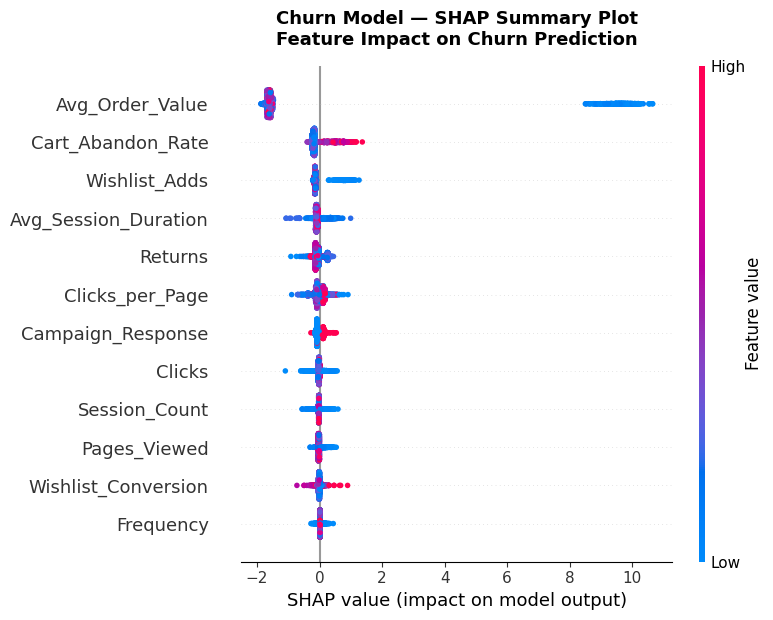

Saved → reports/shap_churn_summary.png ✅


In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_churn,
    X_test_c,
    plot_type="dot",
    show=False,
    max_display=12
)
plt.title(
    "Churn Model — SHAP Summary Plot\n"
    "Feature Impact on Churn Prediction",
    fontsize=13, fontweight="bold", pad=15
)
plt.tight_layout()
plt.savefig(
    "../reports/shap_churn_summary.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_churn_summary.png ✅")

### 3.SHAP Bar Plot:

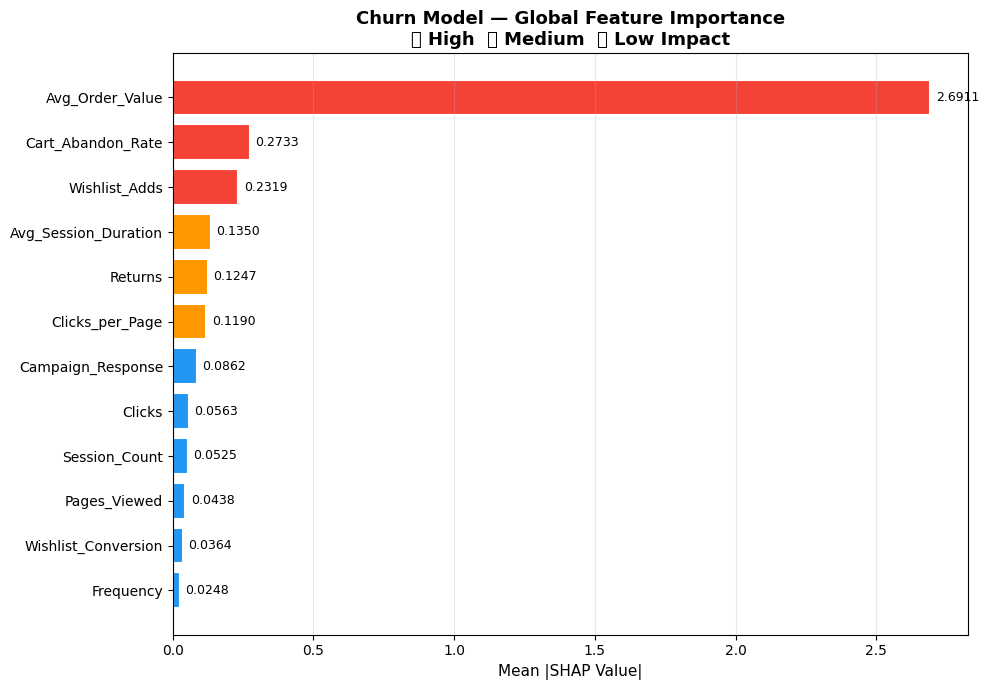

Saved → reports/shap_churn_bar.png ✅


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    "#F44336" if i < 3 else
    "#FF9800" if i < 6 else
    "#2196F3"
    for i in range(len(shap_churn_mean))
]

ax.barh(
    shap_churn_mean.index[::-1],
    shap_churn_mean.values[::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=1.5
)
ax.set_xlabel("Mean |SHAP Value|", fontsize=11)
ax.set_title(
    "Churn Model — Global Feature Importance\n"
    "🔴 High  🟠 Medium  🔵 Low Impact",
    fontsize=13, fontweight="bold"
)
ax.grid(axis="x", alpha=0.3)

# Add value labels
for i, (val, name) in enumerate(
    zip(shap_churn_mean.values[::-1],
        shap_churn_mean.index[::-1])
):
    ax.text(
        val + 0.02, i,
        f"{val:.4f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "../reports/shap_churn_bar.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_churn_bar.png ✅")

### 4.SHAP Dependencies Plot:

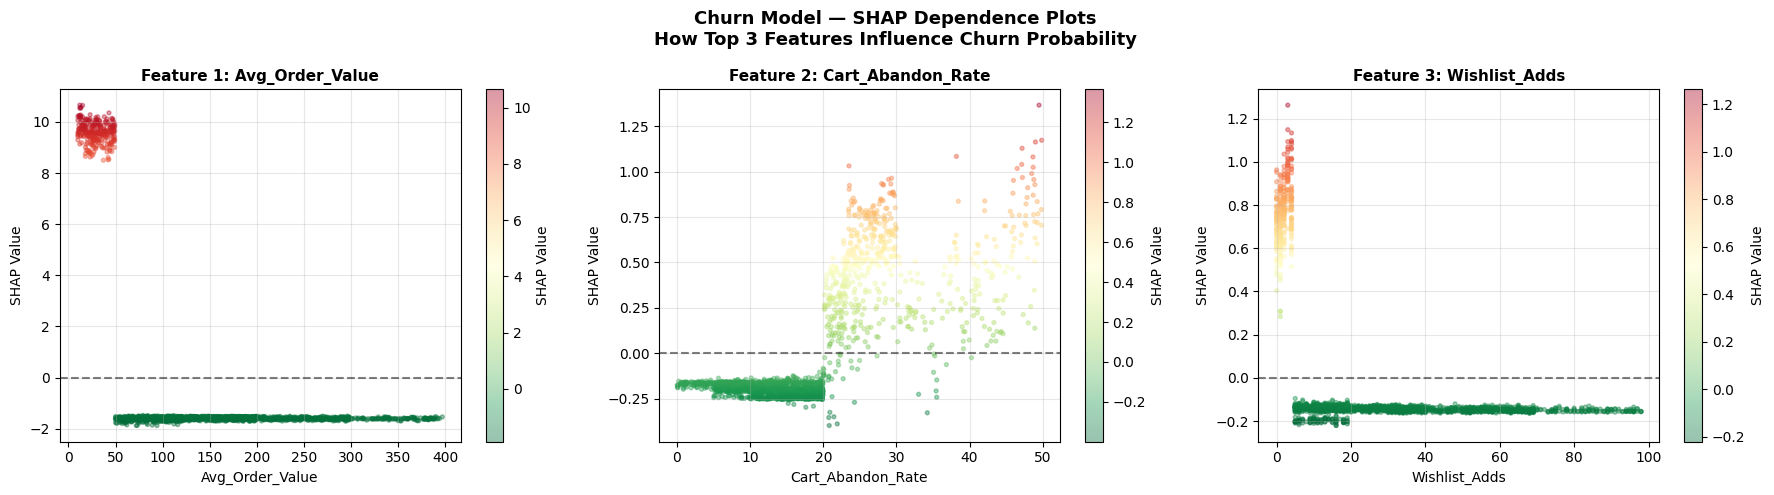

Saved → reports/shap_churn_dependence.png ✅

  Top 3 features:
  1. Avg_Order_Value
  2. Cart_Abandon_Rate
  3. Wishlist_Adds


In [6]:
top3_churn = shap_churn_mean.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Churn Model — SHAP Dependence Plots\n"
    "How Top 3 Features Influence Churn Probability",
    fontsize=13, fontweight="bold"
)

for i, feat in enumerate(top3_churn):
    feat_idx = list(X_test_c.columns).index(feat)
    sc = axes[i].scatter(
        X_test_c[feat],
        shap_churn[:, feat_idx],
        c=shap_churn[:, feat_idx],
        cmap="RdYlGn_r",
        alpha=0.4, s=8
    )
    axes[i].axhline(
        y=0, color="black",
        linestyle="--", alpha=0.5,
        label="No impact"
    )
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel("SHAP Value", fontsize=10)
    axes[i].set_title(
        f"Feature {i+1}: {feat}",
        fontsize=11, fontweight="bold"
    )
    axes[i].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label="SHAP Value")

plt.tight_layout()
plt.savefig(
    "../reports/shap_churn_dependence.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_churn_dependence.png ✅")
print(f"\n  Top 3 features:")
for i, f in enumerate(top3_churn, 1):
    print(f"  {i}. {f}")

---
### 📋 Churn Model — SHAP Business Interpretation

---

**Global Feature Importance Summary:**

| Rank | Feature | SHAP Value | Business Meaning |
|------|---------|-----------|-----------------|
| 1 | Avg_Order_Value | 2.6911 | Spending level dominates all decisions |
| 2 | Cart_Abandon_Rate | 0.2733 | Friction in purchase journey |
| 3 | Wishlist_Adds | 0.2319 | Product interest and intent |
| 4 | Avg_Session_Duration | 0.1350 | Engagement depth |
| 5 | Returns | 0.1247 | Satisfaction signal |
| 6 | Clicks_per_Page | 0.1190 | Browsing engagement quality |

---

### Feature 1 — Avg_Order_Value

Avg_Order_Value is the single most influential churn predictor,
with a SHAP magnitude approximately 10× larger than the
second most important feature.

The SHAP dependence plot suggests a clear behavioural pattern:

- Customers with **higher Avg_Order_Value** produce strongly **negative SHAP values**, pushing predictions toward **retention**.
- Customers with **lower Avg_Order_Value** generate **positive SHAP contributions**, increasing **churn probability**.

This indicates that the model strongly associates **higher spending behaviour with long-term customer retention**.

**Business Interpretation**

High spending customers are significantly less likely to be predicted as churners because historical spending behaviour acts as a strong retention signal.

However, this dominance also introduces a **known model blind spot**: high-value customers who begin to disengage may still appear safe due to their historically high order values.

This limitation was also observed during the **edge-case stress test**, where a high-spending but disengaged customer produced a low churn probability.

**Recommended Action**

Retention strategies should be segmented by spending tier.  
For high-spending customers, engagement metrics such as **session frequency trends, purchase intervals, and browsing behaviour** should be monitored alongside order value to detect early disengagement signals.

---

### Feature 2 — Cart_Abandon_Rate

Cart_Abandon_Rate is the second most influential feature and shows a clear directional relationship with churn probability.

The SHAP dependence plot indicates:

- **Low abandonment rates** generate **negative SHAP values**, indicating healthy purchase behaviour.
- **Higher abandonment rates** produce **positive SHAP values**, pushing predictions toward churn.

The effect increases gradually as abandonment rate rises, suggesting that repeated incomplete purchases act as a **cumulative frustration signal**.

**Business Interpretation**

Cart abandonment reflects **friction in the purchase journey**.  
Customers who frequently add items to the cart but fail to complete purchases may be experiencing price sensitivity, user experience issues, or declining purchase intent — all of which are early signals of churn risk.

**Recommended Action**

Customers with abandonment rates above **~25%** should trigger automated **cart recovery campaigns**.  
If abandonment rises above **~40%**, retention priority should increase, combining recovery incentives with engagement monitoring.

---

### Feature 3 — Wishlist_Adds

Wishlist_Adds is the third most influential feature and acts as a strong **engagement and purchase intent indicator**.

SHAP analysis shows the following behavioural trend:

- **Low wishlist activity (0–5 adds)** produces **positive SHAP values**, indicating weaker engagement and higher churn risk.
- **Higher wishlist activity** generates **negative SHAP values**, signalling active product interest and lower churn probability.

**Business Interpretation**

Wishlist behaviour reflects **latent purchase intent**.  
Customers who regularly add products to wishlists remain engaged with the platform even if purchases are delayed.

Conversely, customers with **no wishlist activity combined with declining purchases** may indicate full behavioural disengagement.

**Recommended Action**

Monitor customers whose wishlist activity drops to **zero for consecutive months**.  
Target these customers with **personalised product recommendation campaigns** based on previously viewed or wishlisted categories.

Wishlist reactivation campaigns typically require **lower incentive costs** compared to full win-back campaigns.

---

### Combined Retention Strategy — SHAP Driven

| Customer Profile | SHAP Signal | Recommended Action |
|-----------------|------------|-------------------|
| High AOV + Low Abandon | Strong retention signal | Monitor engagement trend |
| Low AOV + High Abandon | Strong churn signal | Immediate retention incentive |
| High AOV + High Abandon | Mixed signal | Investigate price sensitivity or UX friction |
| Any AOV + Zero Wishlist | Emerging churn risk | Product recommendation campaign |
| Low Session Duration | Early disengagement signal | Re-engagement email sequence |

The interaction of **Avg_Order_Value**, **Cart_Abandon_Rate**, and **Wishlist_Adds** creates a three-dimensional behavioural signal capturing:

1. Customer spending power  
2. Purchase friction  
3. Product engagement

Together these dimensions provide a richer **customer health signal** than churn probability alone and enable more targeted retention strategies.

---
## Section 3 — LTV Model SHAP Analysis

### What We Are Measuring

In this section, SHAP analysis is applied to the **RandomForest Lifetime Value (LTV) model** to understand which behavioral features most strongly influence predicted customer revenue.

Unlike the churn model, which predicts a **binary outcome (churn vs retain)**, the LTV model predicts a **continuous value representing the expected total revenue generated by a customer**.

SHAP values therefore explain **how each feature pushes the predicted lifetime value higher or lower relative to the model's baseline prediction**.

For this model, the baseline prediction corresponds to the **average customer lifetime value of approximately $7,472**.

---

### Interpreting SHAP Values for LTV

SHAP values in the LTV model represent **dollar-level contributions** to the final prediction:

- **Positive SHAP values** increase predicted lifetime value  
- **Negative SHAP values** decrease predicted lifetime value  

For example:

- Higher spending behaviour may contribute **positive SHAP values**, raising the predicted LTV.
- Lower engagement or weak purchasing behaviour may produce **negative SHAP contributions**, reducing expected revenue.

This allows us to identify **which behavioural signals drive customer value growth** and which behaviours indicate **lower long-term revenue potential**.

---

### Analysis Goals

The SHAP analysis for the LTV model aims to answer three key questions:

**1. Global Drivers of Customer Value**

Which behavioural features have the **largest overall impact on predicted lifetime value** across the entire customer base?

---

**2. Directional Feature Effects**

How do changes in specific features influence predicted LTV?

For example:
- Does higher order value consistently increase predicted lifetime value?
- Does increased engagement translate into higher long-term revenue?

---

**3. Business Strategy Insights**

By understanding which behaviours drive LTV, businesses can:

- identify **high-value customer segments**
- prioritise **customer retention investment**
- design strategies to **increase long-term customer revenue**

Ultimately, this analysis helps transform the LTV model from a simple revenue predictor into a **strategic tool for customer value optimisation**.

### 1.Visualising LTV SHAP Values:

In [7]:
print("=" * 55)
print("   LTV MODEL — SHAP ANALYSIS")
print("=" * 55)
print("  Computing SHAP values...")

ltv_explainer = shap.TreeExplainer(ltv_model)
shap_ltv      = ltv_explainer.shap_values(X_test_l)

shap_ltv_mean = pd.Series(
    np.abs(shap_ltv).mean(axis=0),
    index=X_test_l.columns
).sort_values(ascending=False)

print("\n  Top 12 Features by Mean |SHAP|:")
print("  " + "-" * 45)
for i, (feat, val) in enumerate(
    shap_ltv_mean.items(), 1
):
    bar = "█" * int(val * 5)
    print(f"  {i:02d}. {feat:<30} {val:.2f} {bar}")

print("\n" + "=" * 55)
print("   LTV SHAP VALUES COMPUTED ✅")
print("=" * 55)

   LTV MODEL — SHAP ANALYSIS
  Computing SHAP values...

  Top 12 Features by Mean |SHAP|:
  ---------------------------------------------
  01. Frequency                      4210.87 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

### 2.SHAP Summary Plot:

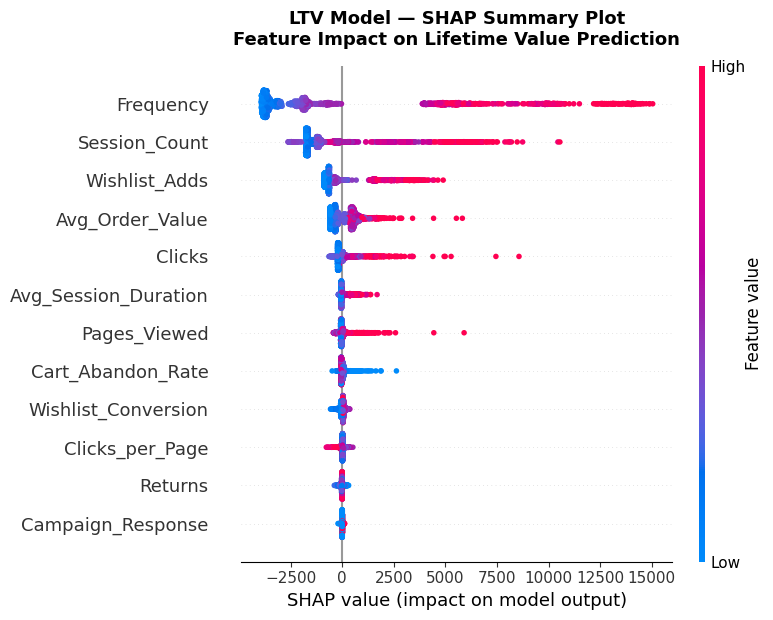

Saved → reports/shap_ltv_summary.png ✅


In [8]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_ltv,
    X_test_l,
    plot_type="dot",
    show=False,
    max_display=12
)
plt.title(
    "LTV Model — SHAP Summary Plot\n"
    "Feature Impact on Lifetime Value Prediction",
    fontsize=13, fontweight="bold", pad=15
)
plt.tight_layout()
plt.savefig(
    "../reports/shap_ltv_summary.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_ltv_summary.png ✅")

### 3.SHAP Bar Plot:

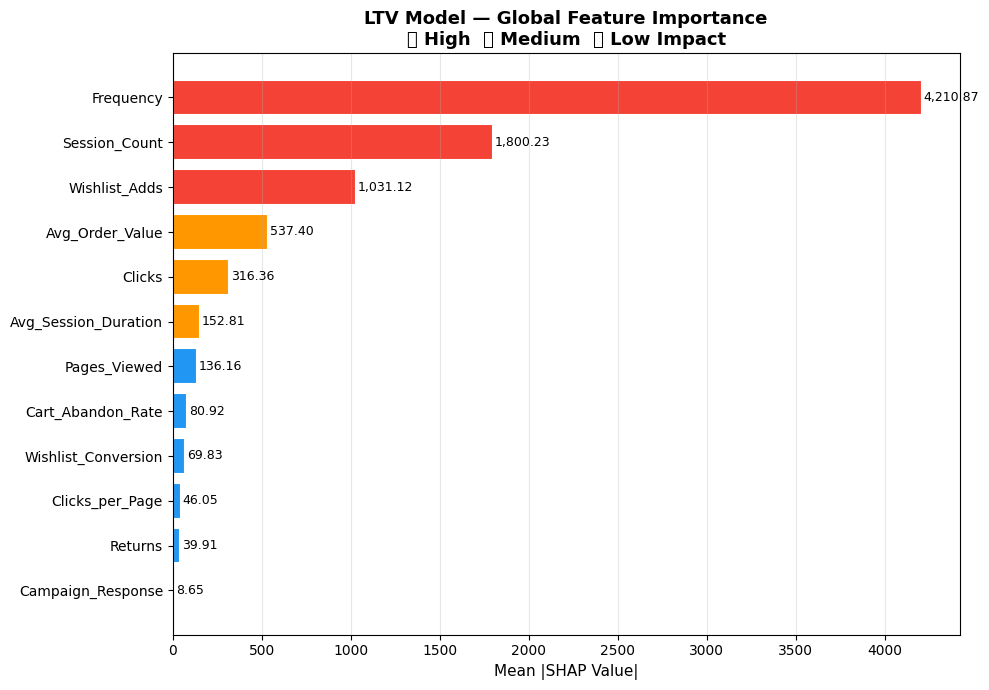

Saved → reports/shap_ltv_bar.png ✅


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    "#F44336" if i < 3 else
    "#FF9800" if i < 6 else
    "#2196F3"
    for i in range(len(shap_ltv_mean))
]

ax.barh(
    shap_ltv_mean.index[::-1],
    shap_ltv_mean.values[::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=1.5
)
ax.set_xlabel("Mean |SHAP Value|", fontsize=11)
ax.set_title(
    "LTV Model — Global Feature Importance\n"
    "🔴 High  🟠 Medium  🔵 Low Impact",
    fontsize=13, fontweight="bold"
)
ax.grid(axis="x", alpha=0.3)

for i, (val, name) in enumerate(
    zip(shap_ltv_mean.values[::-1],
        shap_ltv_mean.index[::-1])
):
    ax.text(
        val + 10, i,
        f"{val:,.2f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "../reports/shap_ltv_bar.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_ltv_bar.png ✅")

### 4.SHAP Dependencie Plot:

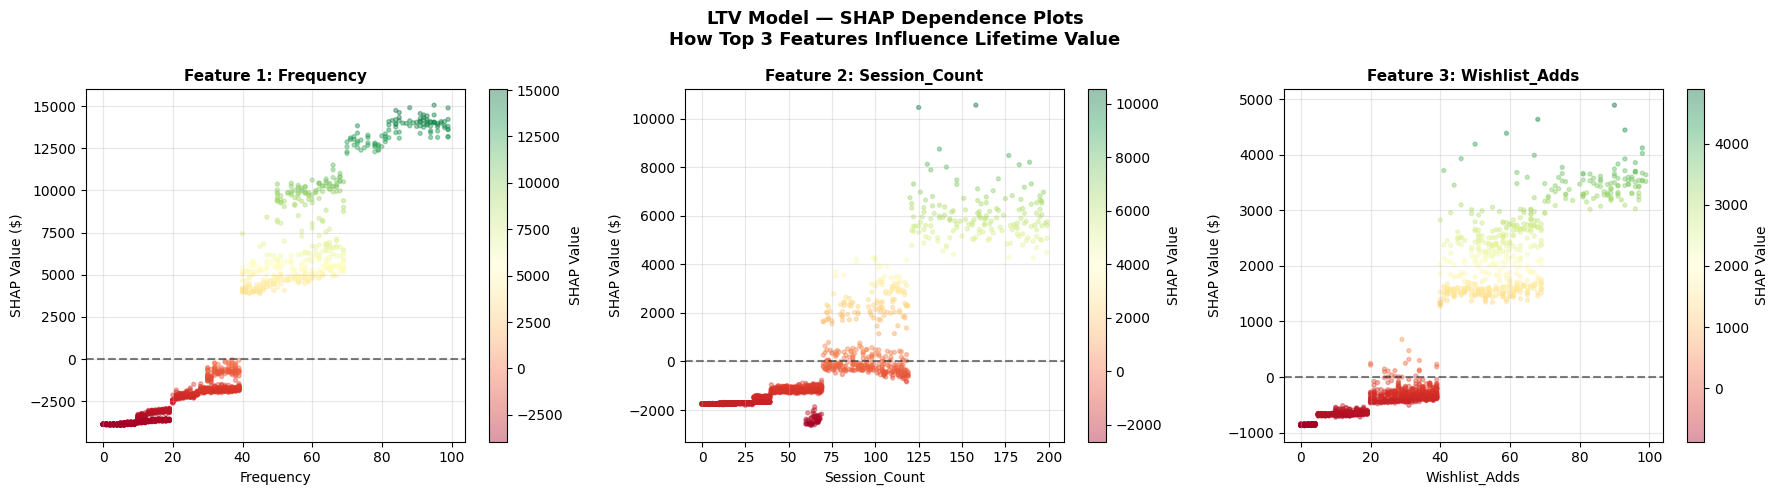

Saved → reports/shap_ltv_dependence.png ✅

  Top 3 LTV features:
  1. Frequency
  2. Session_Count
  3. Wishlist_Adds


In [10]:
top3_ltv = shap_ltv_mean.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "LTV Model — SHAP Dependence Plots\n"
    "How Top 3 Features Influence Lifetime Value",
    fontsize=13, fontweight="bold"
)

for i, feat in enumerate(top3_ltv):
    feat_idx = list(X_test_l.columns).index(feat)
    sc = axes[i].scatter(
        X_test_l[feat],
        shap_ltv[:, feat_idx],
        c=shap_ltv[:, feat_idx],
        cmap="RdYlGn",
        alpha=0.4, s=8
    )
    axes[i].axhline(
        y=0, color="black",
        linestyle="--", alpha=0.5,
        label="No impact"
    )
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel("SHAP Value ($)", fontsize=10)
    axes[i].set_title(
        f"Feature {i+1}: {feat}",
        fontsize=11, fontweight="bold"
    )
    axes[i].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label="SHAP Value")

plt.tight_layout()
plt.savefig(
    "../reports/shap_ltv_dependence.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_ltv_dependence.png ✅")
print(f"\n  Top 3 LTV features:")
for i, f in enumerate(top3_ltv, 1):
    print(f"  {i}. {f}")

---
### 📋 LTV Model — SHAP Business Interpretation

---

**Global Feature Importance Summary:**

| Rank | Feature | SHAP Value | Business Meaning |
|------|---------|-----------|-----------------|
| 1 | Frequency | 4,210.87 | Purchase habit dominates LTV |
| 2 | Session_Count | 1,800.23 | Platform engagement volume |
| 3 | Wishlist_Adds | 1,031.12 | Product interest breadth |
| 4 | Avg_Order_Value | 537.40 | Spending per transaction |
| 5 | Clicks | 316.36 | Browsing engagement depth |
| 6 | Avg_Session_Duration | 152.81 | Session quality signal |

**Key contrast with churn model:**

| | Churn Model | LTV Model |
|--|------------|-----------|
| Top feature | Avg_Order_Value | Frequency |
| Second feature | Cart_Abandon_Rate | Session_Count |
| Third feature | Wishlist_Adds | Wishlist_Adds |

Churn is driven by spending level and friction.
LTV is driven by behavioral volume and habit.
This distinction has direct strategic implications.

---

**Feature 1 — Frequency**

Most influential LTV predictor with SHAP value
of 4,210 — more than twice the second feature.

SHAP dependence plot reveals a continuous
positive relationship with two distinct zones:
- Below 20 purchases → SHAP -2,500
  → customer generates below average LTV
- Above 40 purchases → SHAP 10,000+
  → customer generates significantly above
  average LTV with accelerating returns

**Business Interpretation:**
Purchase frequency is the single strongest
predictor of customer lifetime value.
Customers who purchase more than 40 times
are disproportionately valuable — their LTV
contribution is non-linear and accelerating.

**Recommended Action:**
Identify customers approaching the 20-purchase
milestone and apply targeted incentives to
push them into the high-frequency segment.
Loyalty programmes should reward frequency
progression not just total spend.
A customer making their 18th purchase is
more valuable to retain than their total
spend history suggests.

---

**Feature 2 — Session_Count**

Second most influential LTV predictor with
a clear behavioral threshold visible in
the dependence plot.

SHAP dependence plot reveals:
- Below 75 sessions → SHAP -2,000
  → below average LTV contribution
- Above 75 sessions → positive SHAP
  → above average LTV contribution
- Threshold at approximately 75 sessions
  marks transition from low to high value

**Business Interpretation:**
Session volume reflects platform habit formation.
Customers who visit the platform more than
75 times have developed genuine browsing habits
that translate directly into higher lifetime value.
This is a leading indicator — session behavior
precedes purchase behavior.

**Recommended Action:**
Monitor session count trajectory for new customers.
Customers who reach 50 sessions within first
6 months are on track to become high-LTV customers.
Re-engagement campaigns should target customers
whose session frequency is declining — this is
an early warning signal for LTV erosion before
churn actually occurs.

---

**Feature 3 — Wishlist_Adds**

Third most influential LTV predictor and the
only feature appearing in top 3 for both
churn and LTV models.

SHAP dependence plot reveals:
- Below 20 wishlist adds → SHAP -1,000
  → below average LTV
- Above 40 wishlist adds → SHAP 3,000+
  → significantly above average LTV
- Gradual continuous relationship without
  sharp threshold — more adds = more value

**Business Interpretation:**
Wishlist behavior is the strongest cross-model
signal in the entire feature set.
High wishlist activity indicates:
- Broad product interest across categories
- Active engagement with product discovery
- Intent to purchase across multiple items
- Emotional connection to the platform

Customers who wishlist extensively are both
less likely to churn AND more likely to
generate high lifetime value.

**Recommended Action:**
Wishlist data is underutilised in most retention
systems. Consider:
- Personalised price drop notifications for
  wishlisted items → drives purchase completion
- Wishlist sharing features → social engagement
  → higher session volume
- Wishlist-based product recommendations →
  increases wishlist size → increases LTV signal

---

**Combined LTV Strategy — SHAP Driven:**

| Customer Segment | SHAP Profile | Strategy |
|-----------------|-------------|----------|
| High Frequency (40+) | LTV $15,000+ | VIP retention — prevent churn at all cost |
| Growing (20-40 purchases) | LTV $5,000-10,000 | Frequency acceleration incentives |
| Low Frequency (<20) | LTV below average | Habit formation campaigns |
| High Session, Low Purchase | Mixed signal | Convert browsers to buyers |
| High Wishlist, Low Purchase | High potential | Price sensitivity offers |

**The highest ROI retention segment:**
Customers with Frequency 30-40 + Session_Count 60-80
+ Wishlist_Adds 30-50 are approaching the high-value
threshold across all three top features simultaneously.
A targeted intervention at this inflection point
produces the highest LTV uplift per marketing dollar.

# Section 4 — Cross Model Strategic Insights
### Objective

The goal of this section is to compare SHAP feature importance across the Churn Prediction model and the LTV Prediction model in order to understand:

Which features influence both churn risk and lifetime value

Which features are unique churn drivers

Which features primarily influence long-term revenue generation

How businesses can design integrated retention and growth strategies

Understanding these differences allows organizations to move from single-model decision making to holistic customer value management.

In [11]:
# ── Normalising SHAP Values For Comparison ─────────────
shap_churn_norm = shap_churn_mean / shap_churn_mean.max()
shap_ltv_norm   = shap_ltv_mean   / shap_ltv_mean.max()

# ── Combining DataFrame ────────────────────────────────
cross_df = pd.DataFrame({
    "Churn SHAP (norm)" : shap_churn_norm,
    "LTV SHAP (norm)"   : shap_ltv_norm,
}).fillna(0).sort_values(
    "Churn SHAP (norm)", ascending=False
)

# ── Classifying Features ─────────────────────────────────
def classify(row):
    churn = row["Churn SHAP (norm)"]
    ltv   = row["LTV SHAP (norm)"]
    if churn > 0.05 and ltv > 0.05:
        return "🔴 Both Models"
    elif churn > 0.05:
        return "🟠 Churn Only"
    elif ltv > 0.05:
        return "🔵 LTV Only"
    else:
        return "⚪ Low Impact"

cross_df["Role"] = cross_df.apply(classify, axis=1)

print("=" * 65)
print("   CROSS MODEL FEATURE IMPORTANCE COMPARISON")
print("=" * 65)
print(f"\n  {'Feature':<30} {'Churn':>10} {'LTV':>10} {'Role'}")
print("  " + "-" * 60)
for feat, row in cross_df.iterrows():
    print(
        f"  {feat:<30}"
        f" {row['Churn SHAP (norm)']:>10.4f}"
        f" {row['LTV SHAP (norm)']:>10.4f}"
        f"  {row['Role']}"
    )

print("\n" + "=" * 65)
print("   FEATURE ROLE SUMMARY")
print("=" * 65)
for role in [
    "🔴 Both Models",
    "🟠 Churn Only",
    "🔵 LTV Only",
    "⚪ Low Impact"
]:
    features = cross_df[cross_df["Role"] == role].index.tolist()
    print(f"\n  {role}:")
    for f in features:
        print(f"    → {f}")
print("=" * 65)

   CROSS MODEL FEATURE IMPORTANCE COMPARISON

  Feature                             Churn        LTV Role
  ------------------------------------------------------------
  Avg_Order_Value                    1.0000     0.1276  🔴 Both Models
  Cart_Abandon_Rate                  0.1016     0.0192  🟠 Churn Only
  Wishlist_Adds                      0.0862     0.2449  🔴 Both Models
  Avg_Session_Duration               0.0501     0.0363  🟠 Churn Only
  Returns                            0.0463     0.0095  ⚪ Low Impact
  Clicks_per_Page                    0.0442     0.0109  ⚪ Low Impact
  Campaign_Response                  0.0320     0.0021  ⚪ Low Impact
  Clicks                             0.0209     0.0751  🔵 LTV Only
  Session_Count                      0.0195     0.4275  🔵 LTV Only
  Pages_Viewed                       0.0163     0.0323  ⚪ Low Impact
  Wishlist_Conversion                0.0135     0.0166  ⚪ Low Impact
  Frequency                          0.0092     1.0000  🔵 LTV Only

   FEA

### Visualistzation:

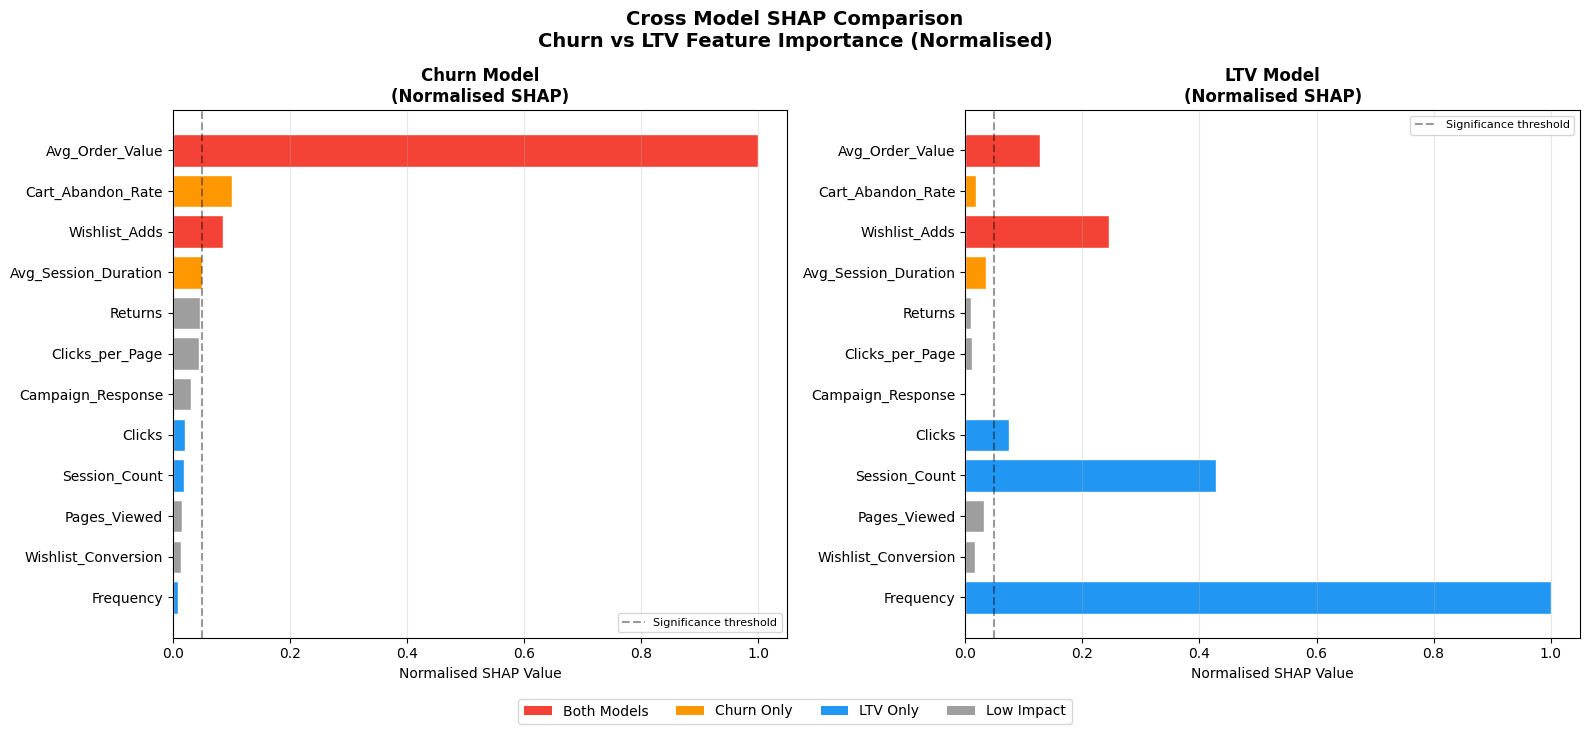

Saved → reports/shap_cross_model.png ✅


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Cross Model SHAP Comparison\n"
    "Churn vs LTV Feature Importance (Normalised)",
    fontsize=14, fontweight="bold"
)

role_colors = {
    "🔴 Both Models" : "#F44336",
    "🟠 Churn Only"  : "#FF9800",
    "🔵 LTV Only"    : "#2196F3",
    "⚪ Low Impact"  : "#9E9E9E",
}

colors = [
    role_colors[cross_df.loc[f, "Role"]]
    for f in cross_df.index
]

# Churn importance
axes[0].barh(
    cross_df.index[::-1],
    cross_df["Churn SHAP (norm)"][::-1],
    color=colors[::-1],
    edgecolor="white"
)
axes[0].set_title(
    "Churn Model\n(Normalised SHAP)",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Normalised SHAP Value")
axes[0].grid(axis="x", alpha=0.3)
axes[0].axvline(x=0.05, color="black",
    linestyle="--", alpha=0.4,
    label="Significance threshold"
)
axes[0].legend(fontsize=8)

# LTV importance
axes[1].barh(
    cross_df.index[::-1],
    cross_df["LTV SHAP (norm)"][::-1],
    color=colors[::-1],
    edgecolor="white"
)
axes[1].set_title(
    "LTV Model\n(Normalised SHAP)",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Normalised SHAP Value")
axes[1].grid(axis="x", alpha=0.3)
axes[1].axvline(x=0.05, color="black",
    linestyle="--", alpha=0.4,
    label="Significance threshold"
)
axes[1].legend(fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", label="Both Models"),
    Patch(facecolor="#FF9800", label="Churn Only"),
    Patch(facecolor="#2196F3", label="LTV Only"),
    Patch(facecolor="#9E9E9E", label="Low Impact"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig(
    "../reports/shap_cross_model.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved → reports/shap_cross_model.png ✅")

---
### 📋 Cross Model SHAP — Business Interpretation

To enable comparison between the churn and LTV models,
SHAP feature importance values were **normalised relative
to the most important feature within each model**.

A value of **1.0 represents the most influential feature**
in that model, while other values indicate importance
relative to that feature.

Features were classified into three strategic roles:

- 🔴 **Both Models** → influence both churn probability and LTV prediction  
- 🟠 **Churn Only** → primarily signal dissatisfaction or disengagement  
- 🔵 **LTV Only** → represent behavioural patterns associated with long-term revenue generation  

---

### Feature Role Classification

| Feature | Churn SHAP | LTV SHAP | Role |
|---------|-----------|---------|------|
| Avg_Order_Value | 1.0000 | 0.1276 | 🔴 Both Models |
| Wishlist_Adds | 0.0862 | 0.2449 | 🔴 Both Models |
| Cart_Abandon_Rate | 0.1016 | 0.0192 | 🟠 Churn Only |
| Avg_Session_Duration | 0.0501 | 0.0363 | 🟠 Churn Only |
| Frequency | 0.0092 | 1.0000 | 🔵 LTV Only |
| Session_Count | 0.0195 | 0.4275 | 🔵 LTV Only |
| Clicks | 0.0209 | 0.0751 | 🔵 LTV Only |

The comparison reveals that **customer retention and customer value are influenced by different behavioural signals**, although a small number of features affect both models simultaneously.

---

## 🔴 Universal Customer Health Signals

**Avg_Order_Value** and **Wishlist_Adds** influence both churn prediction and lifetime value estimation.

These features represent **core indicators of customer relationship strength**.

| Feature | Churn Signal | LTV Signal |
|---------|-------------|-----------|
| Avg_Order_Value | Higher spending reduces churn risk | Higher spending increases LTV |
| Wishlist_Adds | Low product interest increases churn risk | High product discovery increases LTV |

### Strategic Implication

Because these signals influence **both retention and revenue**, they represent the **most valuable behavioural metrics in the dataset**.

A combined **Customer Health Score** based on:

- Average order value tier  
- Wishlist engagement level  

could provide a **single operational metric predicting both churn risk and revenue potential**.

---

## 🟠 Churn-Specific Signals — Customer Experience Friction

**Cart_Abandon_Rate** and **Avg_Session_Duration** strongly influence churn predictions but contribute little to lifetime value estimation.

These features capture **short-term dissatisfaction or purchasing friction**.

Examples include:

- checkout difficulties  
- pricing hesitation  
- confusing product pages  
- payment issues  

### Strategic Implication

These signals should trigger **immediate customer experience interventions** rather than promotional discounts.

For example:

- reducing checkout friction  
- simplifying payment processes  
- improving product page clarity  

A high-value customer showing rising cart abandonment is **not necessarily losing interest in the brand**, but may be encountering a **purchase barrier**.

---

## 🔵 LTV-Specific Signals — Habit Formation and Engagement

**Frequency**, **Session_Count**, and **Clicks** dominate the LTV model.

These features represent **long-term behavioural intensity** rather than immediate satisfaction.

High values indicate customers who:

- interact frequently with the platform  
- explore multiple products  
- develop consistent purchasing habits  

### Strategic Implication

These signals are ideal for **customer value segmentation and marketing budget allocation**.

They should guide decisions such as:

- loyalty programme targeting  
- personalised marketing investment  
- retention budget allocation  

Importantly, **high-frequency customers are not necessarily at lower churn risk**, but they generate significantly higher revenue over time.

---

## Key Cross-Model Insight

The SHAP comparison highlights a fundamental behavioural distinction:

| Model | Behaviour Type | Business Meaning |
|------|---------------|-----------------|
| Churn Model | Friction Signals | Detect dissatisfaction or barriers |
| LTV Model | Habit Signals | Identify customers with long-term value |

In other words:

**Churn models detect problems.**  
**LTV models detect opportunity.**

Companies must therefore manage **both dimensions simultaneously**.

---

## Combined Churn + LTV Decision Framework

The highest business value comes from **combining churn probability with predicted lifetime value**.

| Churn Risk | Predicted LTV | Action | Budget |
|-----------|--------------|--------|--------|
| 🔴 High | 🔴 High | Immediate premium intervention | High |
| 🔴 High | 🟡 Medium | Standard retention offer | Medium |
| 🔴 High | 🟢 Low | Low cost win-back attempt | Low |
| 🟢 Low | 🔴 High | VIP loyalty programme | High |
| 🟢 Low | 🟡 Medium | Engagement maintenance | Low |
| 🟢 Low | 🟢 Low | Automated nurture only | Minimal |

The **highest ROI segment** is:

**High churn risk + high predicted LTV customers.**

For these customers, SHAP insights suggest the following interventions:

- Reduce **Cart_Abandon_Rate** through checkout optimisation  
- Re-engage **Wishlist_Adds** through personalised recommendations  
- Protect **Avg_Order_Value** through value-based offers  
- Stabilise **Session_Count** via re-engagement campaigns  

---

## Data Collection Priorities — SHAP Evidence Based

SHAP analysis also highlights which **additional behavioural signals would most improve future models**.

| Priority | Signal | Improves | Evidence |
|----------|--------|---------|---------|
| 1 | Purchase frequency trend | Both | Frequency dominates LTV |
| 2 | Session frequency trend | LTV | Session_Count strong LTV signal |
| 3 | Cart abandonment reason | Churn | Cart_Abandon_Rate churn-specific |
| 4 | Wishlist conversion rate | Both | Wishlist affects both models |
| 5 | Session depth trend | Churn | Avg_Session_Duration churn signal |

These priorities are **data-driven insights derived directly from SHAP value analysis across both models**, ensuring that future data collection focuses on signals with the highest predictive impact.

---

## Final Strategic Insight

The combined SHAP analysis shows that **customer churn and customer value are driven by fundamentally different behavioural signals**.

- Churn models primarily detect **friction and dissatisfaction**
- LTV models capture **habit formation and engagement intensity**

By combining these two predictive perspectives, organisations can move from **reactive churn prevention toward proactive customer value management**.

This allows retention strategies to focus not only on *who is likely to leave*, but also on *which customers are most valuable to retain*.

In [13]:
print("=" * 60)
print("   SHAP ANALYSIS — COMPLETE ✅")
print("=" * 60)
print("""
  CHURN MODEL (LightGBM):
  ─────────────────────────────────────
  Top Feature    : Avg_Order_Value (1.0000)
  Second Feature : Cart_Abandon_Rate (0.1016)
  Third Feature  : Wishlist_Adds (0.0862)
  Key Finding    : Single feature dominance
                   AOV 10x more important
                   than second feature

  LTV MODEL (RandomForest):
  ─────────────────────────────────────
  Top Feature    : Frequency (1.0000)
  Second Feature : Session_Count (0.4275)
  Third Feature  : Wishlist_Adds (0.2449)
  Key Finding    : More distributed importance
                   Volume and habit drive value

  CROSS MODEL INSIGHTS:
  ─────────────────────────────────────
  Both Models    : Avg_Order_Value, Wishlist_Adds
  Churn Only     : Cart_Abandon_Rate, Avg_Session_Duration
  LTV Only       : Frequency, Session_Count, Clicks
  Low Impact     : Returns, Pages_Viewed, Campaign_Response

  REPORTS SAVED:
  ─────────────────────────────────────
  → reports/shap_churn_summary.png    ✅
  → reports/shap_churn_bar.png        ✅
  → reports/shap_churn_dependence.png ✅
  → reports/shap_ltv_summary.png      ✅
  → reports/shap_ltv_bar.png          ✅
  → reports/shap_ltv_dependence.png   ✅
  → reports/shap_cross_model.png      ✅
""")
print("=" * 60)

   SHAP ANALYSIS — COMPLETE ✅

  CHURN MODEL (LightGBM):
  ─────────────────────────────────────
  Top Feature    : Avg_Order_Value (1.0000)
  Second Feature : Cart_Abandon_Rate (0.1016)
  Third Feature  : Wishlist_Adds (0.0862)
  Key Finding    : Single feature dominance
                   AOV 10x more important
                   than second feature

  LTV MODEL (RandomForest):
  ─────────────────────────────────────
  Top Feature    : Frequency (1.0000)
  Second Feature : Session_Count (0.4275)
  Third Feature  : Wishlist_Adds (0.2449)
  Key Finding    : More distributed importance
                   Volume and habit drive value

  CROSS MODEL INSIGHTS:
  ─────────────────────────────────────
  Both Models    : Avg_Order_Value, Wishlist_Adds
  Churn Only     : Cart_Abandon_Rate, Avg_Session_Duration
  LTV Only       : Frequency, Session_Count, Clicks
  Low Impact     : Returns, Pages_Viewed, Campaign_Response

  REPORTS SAVED:
  ─────────────────────────────────────
  → reports/shap

---
## Section 5 — Production Recommendations

### Objective

The SHAP analysis performed in the previous sections converts model predictions into **actionable business intelligence**.

Rather than simply predicting churn or lifetime value, the system now explains:

- **why customers churn**
- **what drives customer value**
- **which behavioural signals require intervention**

This transforms the project from a predictive model into a **complete customer decision support framework**.

---

## Three Levels of Insight

### 1. Feature-Level Insight

SHAP analysis quantifies the **contribution and direction of every feature** in the model.

This means that for every prediction we can explain:

- which behavioural signals increased churn risk
- which signals decreased churn risk
- which behaviours increased predicted lifetime value

As a result, business teams can understand **exactly why a customer received a specific churn probability or LTV prediction**.

---

### 2. Model-Level Insight

Although both models were trained on the **same 12 behavioural features**, they rely on **different behavioural signals**.

| Model | Primary Drivers |
|------|----------------|
| Churn Model | Spending level and purchase friction |
| LTV Model | Engagement intensity and behavioural volume |

This distinction is important because it prevents businesses from **confusing retention drivers with revenue drivers**.

For example:

- Cart abandonment signals **experience friction**
- Frequency signals **long-term purchasing habits**

Each requires a **different intervention strategy**.

---

### 3. System-Level Insight

Combining both models with SHAP explanations creates a **complete customer intelligence system**.

| Question | Component |
|--------|-----------|
| Who is at risk of leaving? | Churn model |
| How valuable is the customer? | LTV model |
| Why is the customer at risk? | SHAP churn explanation |
| What drives their revenue potential? | SHAP LTV explanation |
| What action should be taken? | Combined decision framework |

This integrated view allows organisations to move from **reactive churn management** to **proactive customer value optimisation**.

---

## Production Implementation Recommendations

### Immediate (No New Data Required)

The following actions can be implemented using the **existing dataset and models**.

- Deploy **combined churn and LTV scoring**
- Create a **customer health score**
  using Avg_Order_Value and Wishlist_Adds
- Allocate **retention budgets based on LTV tiers**
- Trigger **cart abandonment alerts** when rates exceed 25%

These steps allow businesses to **immediately operationalise model insights**.

---

### Short-Term Improvements (Data Pipeline Enhancements)

Additional behavioural tracking will significantly improve prediction quality.

Recommended signals to collect:

- **Frequency trajectory over time**
- **Weekly Session_Count trends**
- **Wishlist_Adds velocity changes**
- **Cart abandonment reasons**

These signals will allow the models to detect **early behavioural changes before churn occurs**.

---

### Long-Term Data Strategy (Infrastructure Level)

Future system improvements may include deeper behavioural tracking.

Potential additions include:

- Transaction-level purchase timestamps
- Customer tenure progression tracking
- Seasonal behaviour pattern monitoring
- Cohort-level retention curve analysis

These signals enable **advanced lifecycle modelling and long-term customer forecasting**.

---

## Reports Generated From SHAP Analysis

The explainability pipeline produces multiple visual reports that help stakeholders interpret model behaviour.

| Report | Description |
|------|-------------|
| shap_churn_summary.png | SHAP summary dot plot showing churn feature direction |
| shap_churn_bar.png | Feature importance ranking for churn model |
| shap_churn_dependence.png | Dependence plots for top churn drivers |
| shap_ltv_summary.png | SHAP summary dot plot for LTV model |
| shap_ltv_bar.png | Feature importance ranking for LTV model |
| shap_ltv_dependence.png | Dependence plots for top LTV drivers |
| shap_cross_model.png | Cross-model feature importance comparison |

These visualisations make model behaviour **transparent, interpretable, and actionable for business stakeholders**.

---